# Reaction Aggregator — Warehouse Analysis

An analyst's tour of the warehouse built by the pipeline. Everything is local and synthetic on purpose: a seeded SQLite source and a DuckDB warehouse, both files under `./data`.

The warehouse is a star schema — three dimensions (`dim_viewer`, `dim_creative`, `dim_session`) and one fact (`fact_expression`) with one row per expression score per timestamp per channel. The sections below follow the three analyst requirements: reactions across a creative's timeline, breakdowns by viewer attributes, and comparisons across creatives.

**Before running:** seed a few sessions so there are audiences and creatives to compare — each session is one viewer watching one creative, drawn deterministically from small fixed pools. This particular set gives a varied example: three genders, three age brackets, three countries, three creatives, and two sessions watching the same creative:

```bash
just seed && just run                          # the default demo session
just seed session-a && just run session-a
just seed session-b && just run session-b
just seed session-e && just run session-e
```

One caveat: DuckDB allows a single writer. If `just run` fails with a lock error while this notebook is open, restart the kernel and re-run.

In [1]:
import os

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

warehouse_path = os.environ.get("WAREHOUSE_DATABASE_PATH", "data/warehouse.duckdb")


def query(sql: str) -> pd.DataFrame:
    connection = duckdb.connect(warehouse_path, read_only=True)
    try:
        return connection.execute(sql).df()
    finally:
        connection.close()

## Row counts per table

In [2]:
row_counts = query("""
    SELECT 'dim_viewer'      AS table_name, COUNT(*) AS row_count FROM dim_viewer
    UNION ALL
    SELECT 'dim_creative'    AS table_name, COUNT(*) AS row_count FROM dim_creative
    UNION ALL
    SELECT 'dim_session'     AS table_name, COUNT(*) AS row_count FROM dim_session
    UNION ALL
    SELECT 'fact_expression' AS table_name, COUNT(*) AS row_count FROM fact_expression
""")

row_counts

,table_name,row_count
0,dim_viewer,4
1,dim_creative,3
2,dim_session,4
3,fact_expression,395328


## Top 10 expressions by mean score

In [3]:
top_expressions = query("""
    SELECT expression, AVG(score) AS mean_score
    FROM fact_expression
    GROUP BY expression
    ORDER BY 2 DESC
    LIMIT 10
""")

top_expressions

,expression,mean_score
0,boredom,0.624324
1,sympathy,0.617543
2,contentment,0.599533
3,doubt,0.599002
4,awkwardness,0.597993
5,interest,0.596324
6,calmness,0.594041
7,envy,0.588488
8,adoration,0.565005
9,desire,0.559309


## Face vs voice mean score per channel

In [4]:
channel_means = query("""
    SELECT channel, AVG(score) AS mean_score
    FROM fact_expression
    GROUP BY channel
    ORDER BY channel
""")

channel_means

,channel,mean_score
0,face,0.501572
1,voice,0.471659


## Reactions across a creative's timeline

Pick the creative with the most sessions and average each expression's face-channel score across all of its sessions, bucketed per second of playback — how the audience's response moves over the creative's duration.

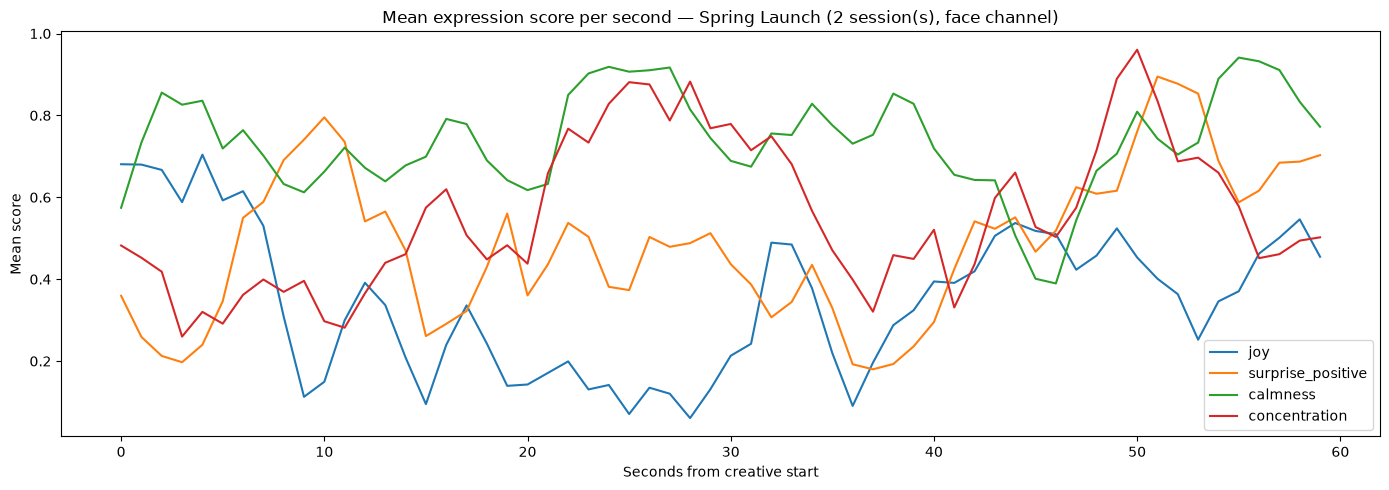

In [5]:
creative_row = query("""
    SELECT fact.creative_id, creative.title, COUNT(DISTINCT fact.session_id) AS session_count
    FROM fact_expression AS fact
    JOIN dim_creative AS creative USING (creative_id)
    GROUP BY fact.creative_id, creative.title
    ORDER BY session_count DESC, fact.creative_id
    LIMIT 1
""")
creative_id = creative_row["creative_id"].iloc[0]
creative_title = creative_row["title"].iloc[0]
session_count = creative_row["session_count"].iloc[0]

expressions_of_interest = ['joy', 'surprise_positive', 'calmness', 'concentration']
expressions_literal = ", ".join(f"'{expression}'" for expression in expressions_of_interest)

time_series = query(f"""
    SELECT timestamp // 1000 AS second, expression, AVG(score) AS mean_score
    FROM fact_expression
    WHERE creative_id = '{creative_id}'
      AND channel = 'face'
      AND expression IN ({expressions_literal})
    GROUP BY second, expression
    ORDER BY second
""")

pivoted = time_series.pivot(index="second", columns="expression", values="mean_score")

figure, axes = plt.subplots(figsize=(14, 5))
for expression in expressions_of_interest:
    if expression in pivoted.columns:
        axes.plot(pivoted.index, pivoted[expression], label=expression)

axes.set_xlabel("Seconds from creative start")
axes.set_ylabel("Mean score")
axes.set_title(f"Mean expression score per second — {creative_title} ({session_count} session(s), face channel)")
axes.legend()
plt.tight_layout()
plt.show()

## Breakdown by viewer attributes

Join the fact to `dim_viewer` and slice mean scores by audience attributes. With a single seeded session there is only one viewer — seed more sessions (see the intro) to make the groups meaningful.

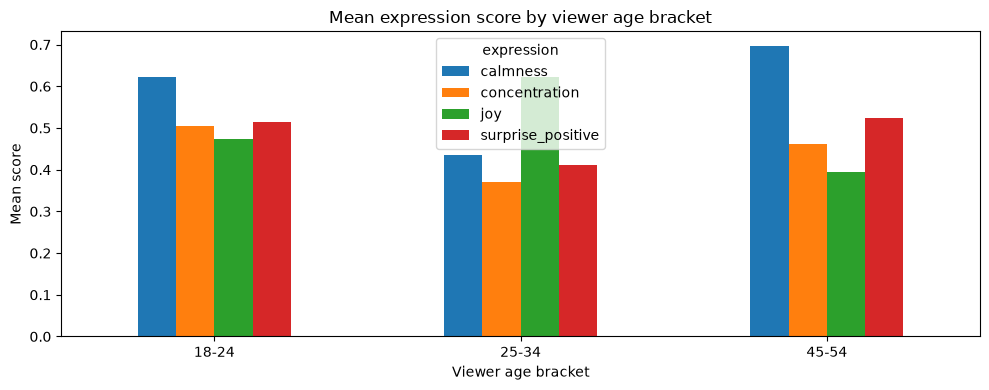

,country,gender,sessions,mean_score
0,DE,nonbinary,1,0.530405
1,GB,female,1,0.460875
2,GB,nonbinary,1,0.472305
3,US,male,1,0.528756


In [6]:
by_age_bracket = query(f"""
    SELECT viewer.age_bracket, fact.expression, AVG(fact.score) AS mean_score
    FROM fact_expression AS fact
    JOIN dim_viewer AS viewer USING (viewer_id)
    WHERE fact.expression IN ({expressions_literal})
    GROUP BY viewer.age_bracket, fact.expression
    ORDER BY viewer.age_bracket, fact.expression
""")

pivoted_by_age = by_age_bracket.pivot(index="age_bracket", columns="expression", values="mean_score")

axes = pivoted_by_age.plot.bar(figsize=(10, 4), rot=0)
axes.set_xlabel("Viewer age bracket")
axes.set_ylabel("Mean score")
axes.set_title("Mean expression score by viewer age bracket")
plt.tight_layout()
plt.show()

query("""
    SELECT viewer.country, viewer.gender,
           COUNT(DISTINCT fact.session_id) AS sessions,
           AVG(fact.score) AS mean_score
    FROM fact_expression AS fact
    JOIN dim_viewer AS viewer USING (viewer_id)
    GROUP BY viewer.country, viewer.gender
    ORDER BY viewer.country, viewer.gender
""")

## Comparison across creatives

Join the fact to `dim_creative` and compare mean scores per creative. Sessions draw their creative from a small fixed pool, so several sessions can watch the same creative — each bar aggregates every session of that creative.

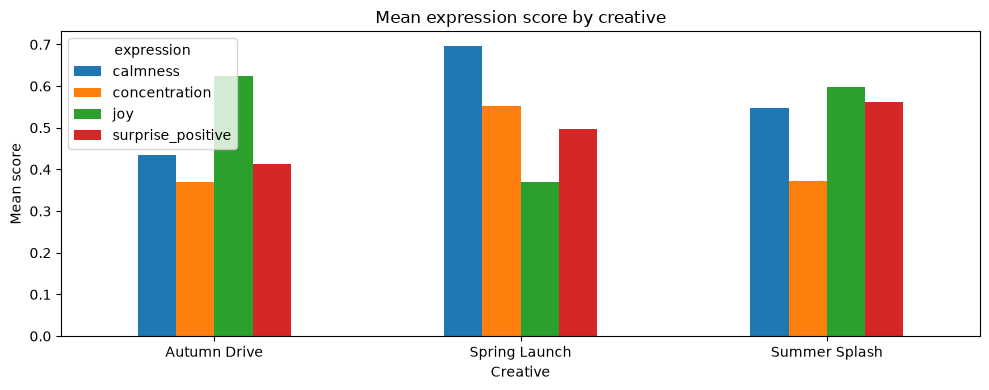

In [7]:
by_creative = query(f"""
    SELECT creative.title, fact.expression,
           COUNT(DISTINCT fact.session_id) AS sessions,
           AVG(fact.score) AS mean_score
    FROM fact_expression AS fact
    JOIN dim_creative AS creative USING (creative_id)
    WHERE fact.expression IN ({expressions_literal})
    GROUP BY creative.title, fact.expression
    ORDER BY creative.title, fact.expression
""")

pivoted_by_creative = by_creative.pivot(index="title", columns="expression", values="mean_score")

axes = pivoted_by_creative.plot.bar(figsize=(10, 4), rot=0)
axes.set_xlabel("Creative")
axes.set_ylabel("Mean score")
axes.set_title("Mean expression score by creative")
plt.tight_layout()
plt.show()